In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import re
import string
import pickle
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

In [3]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
data = pd.read_csv('/content/drive/MyDrive/Datasets/twitter.csv')
data.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [5]:
print(data['class'].value_counts())

class
1    19190
2     4163
0     1430
Name: count, dtype: int64


In [6]:
df_class0 = data[data['class'] == 0]
df_class1 = data[data['class'] == 1].sample(n=3000, random_state=42)
df_class2 = data[data['class'] == 2]

df = pd.concat([df_class0, df_class1, df_class2])
df = df.sample(frac=1, random_state=42)

In [7]:
print(df['class'].value_counts())

class
2    4163
1    3000
0    1430
Name: count, dtype: int64


In [8]:
data = df[["tweet","class"]]

In [9]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

In [10]:
def clean(text):

    text = str(text).lower()

    # remove text in brackets
    text = re.sub(r'\[.*?\]', '', text)

    # remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # remove html tags
    text = re.sub(r'<.*?>+', '', text)

    # remove punctuation
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)

    # remove new lines
    text = re.sub(r'\n', '', text)

    # remove words containing digits
    text = re.sub(r'\w*\d\w*', '', text)

    # remove mentions
    text = re.sub(r'@\w+', '', text)

    # remove extra spaces
    text = " ".join(text.split())

    # stemming + stopword removal
    words = []

    for word in text.split():
        if word not in stop_words:
            words.append(
                stemmer.stem(word)
            )

    text = " ".join(words)

    return text


# Apply cleaning
data["tweet"] = data["tweet"].apply(clean)
data.head()

/tmp/ipykernel_3158/3089310598.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tweet"] = data["tweet"].apply(clean)


,tweet,class
2206,,2
11448,one welcom new eastern panhandl overlord hope ...,2
16802,rt olenoho got bad ass bitch bounc dick,1
17422,rt stephmcmahon sign checkpoint charli well kn...,2
11341,im realli phone kinda guy actual hate talk pho...,2


In [11]:
X=data["tweet"]

y=data["class"]

In [12]:
vectorizer=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X=vectorizer.fit_transform(X)

In [13]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
smote=SMOTE(
    random_state=42
)

X_train_smote,y_train_smote = smote.fit_resample(

    X_train,
    y_train

)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(
n_estimators=500,
max_depth=40,
class_weight="balanced_subsample",
random_state=42,
n_jobs=-1
)

model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=40,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [16]:
pred=model.predict(
    X_test
)

print("\nAccuracy:")
print(
accuracy_score(
y_test,
pred
)
)


print("\nClassification Report:\n")

print(
classification_report(
y_test,
pred
)
)


print("\nConfusion Matrix:\n")

print(
confusion_matrix(
y_test,
pred
)
)


Accuracy:
0.8440954043048284

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.56      0.62       303
           1       0.86      0.82      0.84       590
           2       0.87      0.96      0.92       826

    accuracy                           0.84      1719
   macro avg       0.81      0.78      0.79      1719
weighted avg       0.84      0.84      0.84      1719


Confusion Matrix:

[[170  70  63]
 [ 52 486  52]
 [ 20  11 795]]


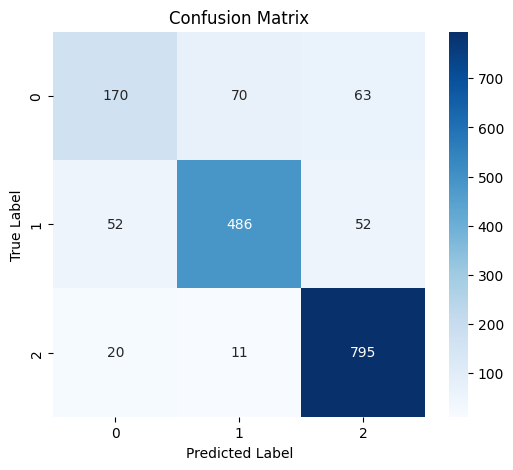

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [18]:
class_names = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neutral"
}

In [19]:
import numpy as np
text = "I hate you stupid people"

text_clean = clean(text)
vec = vectorizer.transform([text_clean])

probs = model.predict(vec.toarray())[0]
label = np.argmax(probs)

print("Text:", text)
print("Prediction:", class_names[label])

Text: I hate you stupid people
Prediction: Hate Speech


In [20]:
samples = [
    "I hate you stupid people",
    "You are so dumb",
    "I love machine learning",
    "Go back to your country",
    "This is a beautiful day"
]

for text in samples:
    cleaned = clean(text)
    vec = vectorizer.transform([cleaned])
    probs = model.predict(vec.toarray())[0]
    label = np.argmax(probs)

    print("\nText:", text)
    print("Prediction:", class_names[label])


Text: I hate you stupid people
Prediction: Hate Speech

Text: You are so dumb
Prediction: Hate Speech

Text: I love machine learning
Prediction: Hate Speech

Text: Go back to your country
Prediction: Hate Speech

Text: This is a beautiful day
Prediction: Hate Speech


In [22]:
import pickle

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

In [23]:
import joblib
joblib.dump(model, 'hate_speech_model.pkl')

['hate_speech_model.pkl']